# Deck writers, read-only reasons and shared node orders

Added in v16.17.0:

- **Radioss and Marc decks are written**, in both engines and byte for byte the same: an OpenRadioss starter deck (`_0000.rad`, optionally with placeholder materials and properties so the starter runs it as is) and an MSC Marc input deck (`.dat`, written by name, since a `.dat` alone stays Tecplot's).
- **Femap writes a series**: `write_sequence` to a `.neu` puts the mesh once and one output set per step.
- **EnSight Fortran binary** files are read and written.
- **Every format read but not written says why** on the conformance page, and a test keeps that list, the registry and the format table in step.
- **The node orders of gmsh, CGNS, GiD, Kratos and Exodus** moved into the shared registry, which fixed Exodus's and Kratos's quadratic hexahedra.

The inputs come from `tests/python/meshes/`, or are built in the notebook.

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

# Keep the outputs readable: the warnings the readers and writers print are discussed in the text.
os.environ.setdefault('MESHIOPLUSPLUS_LOG_LEVEL', 'error')
import meshioplusplus as mp  # noqa: E402

# Head-less, static rendering (no display / live server needed).
pv.OFF_SCREEN = True
pv.set_jupyter_backend('static')

MESHES = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), 'tests', 'python', 'meshes')
TMP = tempfile.mkdtemp()


def path(folder, name):
    return os.path.join(MESHES, folder, name)


def region_array(mesh, names=None):
    '''Per-cell index of the cell region holding each cell (NaN for none), as cell_data.'''
    regions = [r for r in mesh.regions if r.kind == 'cell' and (names is None or r.name in names)]
    flat = np.full(sum(len(c.data) for c in mesh.cells), np.nan)
    for k, r in enumerate(regions):
        flat[r.entries] = k
    out, start = [], 0
    for c in mesh.cells:
        out.append(flat[start:start + len(c.data)])
        start += len(c.data)
    return out


def curved(grid, level=3):
    '''The surface of `grid` with its quadratic cells subdivided, so curved edges look curved.'''
    return grid.extract_surface(nonlinear_subdivision=level, algorithm='dataset_surface')


def to_grid(mesh, cell_data=None, point_data=None, lines=False):
    '''A PyVista grid of `mesh`'s surfaces and solids (through a .vtu, so quadratic cells stay quadratic).'''
    keep = [i for i, c in enumerate(mesh.cells) if c.type not in ('vertex', 'line', 'line3', 'line4') or lines]
    cells = [mesh.cells[i] for i in keep]
    cd = {k: [v[i] for i in keep] for k, v in (cell_data or {}).items()}
    target = os.path.join(TMP, 'render.vtu')
    mp.write(target, mp.Mesh(mesh.points, cells, point_data=point_data or {}, cell_data=cd))
    return pv.read(target)


def gallery(items, ncols=2, size=(760, 460), view=(-1.0, -1.4, 0.45), edges=True, zoom=1.0):
    '''Render `(grid, scalars, title, clim)` items side by side, or with matplotlib when GL is unavailable.'''
    nrows = -(-len(items) // ncols)
    fig = plt.figure(figsize=(5.6 * ncols, 3.6 * nrows))
    for k, (grid, scalars, title, clim) in enumerate(items, start=1):
        try:
            pl = pv.Plotter(off_screen=True, window_size=size)
            pl.add_mesh(grid, scalars=scalars, cmap='turbo', clim=clim, show_edges=edges, edge_color='#333333',
                        line_width=0.6, nan_color='#bbbbbb',
                        scalar_bar_args={'title': scalars, 'vertical': True, 'position_x': 0.82,
                                         'position_y': 0.12, 'height': 0.76, 'width': 0.08})
            pl.view_vector(view, viewup=(0, 1, 0) if view == (0, 0, 1) else (0, 0, 1))
            pl.reset_camera()
            pl.camera.zoom(zoom)
            img = pl.screenshot(return_img=True)
            pl.close()
            ax = fig.add_subplot(nrows, ncols, k)
            ax.imshow(img)
        except Exception as exc:  # pragma: no cover - head-less GL fallback
            print('PyVista render skipped:', exc)
            ax = fig.add_subplot(nrows, ncols, k, projection='3d')
            p = np.asarray(grid.points)
            ax.scatter(p[:, 0], p[:, 1], p[:, 2], s=8)
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

import vtk  # noqa: E402  (the Exodus and EnSight checks below read with VTK)


## A `.dat` write is Tecplot's

Marc decks and Tecplot files share `.dat`. Reading tells them apart by content; a write goes by the name alone, among the formats that can write, so an old Marc deck at the path never makes the new file a Marc deck. Name `marc` to write one.

In [2]:
tri = mp.Mesh(np.array([[0.0, 0, 0], [1, 0, 0], [0, 1, 0]]), [('triangle', np.array([[0, 1, 2]]))])
target = os.path.join(TMP, 'a.dat')
mp.write(target, tri)
with open(target) as f:
    print('by extension:', f.readline().strip(), '(Tecplot)')
mp.write(target, tri, file_format='marc')
print('by name     :', mp.sniff_format(target))
try:
    mp.write(os.path.join(TMP, 'a.frd'), tri)
except mp.WriteError as exc:
    print(exc)

by extension: TITLE = "Written by meshio++ v16.17.0" (Tecplot)
by name     : marc
Format 'frd' can be read but not written. Pick one of ['abaqus', 'ansys', 'ansysInp', 'avsucd', 'cae', 'cgns', 'code_aster', 'dex', 'dolfin-xml', 'elmer', 'ensight', 'exodus', 'febio', 'femap', 'flac3d', 'flux', 'freefem', 'gid', 'gltf', 'gmsh', 'gmsh22', 'h5m', 'hmf', 'ip', 'libmesh', 'lsdyna', 'marc', 'mdpa', 'med', 'medit', 'mfem', 'mff', 'mfm', 'mphbin', 'mphtxt', 'nastran', 'netgen', 'neuroglancer', 'obj', 'off', 'openfoam', 'patran', 'pcd', 'permas', 'ply', 'pmsh', 'pvd', 'pvtp', 'pvtu', 'radioss', 'stl', 'su2', 'svg', 'tecplot', 'tetgen', 'tikz', 'triangle', 'ugrid', 'unv', 'usd', 'vti', 'vtk', 'vtk42', 'vtk51', 'vtkhdf', 'vtm', 'vtp', 'vtr', 'vts', 'vtu', 'wkt', 'xdmf', 'xyz', 'z88', 'zarr']


## An OpenRadioss starter deck, written and read back

`radioss/deck_0000.rad` holds every element card the reader knows, parts, a subset tree, node and element groups and a segment surface. Written back with `stubs=True`, it also gets a `/MAT/LAW1` per material and a `/PROP` per property, so the OpenRadioss starter accepts it on its own (this was checked with the OpenRadioss release of 2026-07-28; the values are placeholders). Pyramids and wedges are written as degenerate bricks, and reading them back gives the same cells.

#RADIOSS STARTER
# Written by meshio++ v16.17.0
/BEGIN
copy
      2019         0
                  kg                   m                   s
                  kg                   m                   s
/MAT/LAW1/21
meshio++ stub material 21
                 1.0                 0.0
                 1.0                 0.3
/MAT/LAW1/22
... 216 lines; 3 materials, 5 properties
same cells  : True
same regions: True


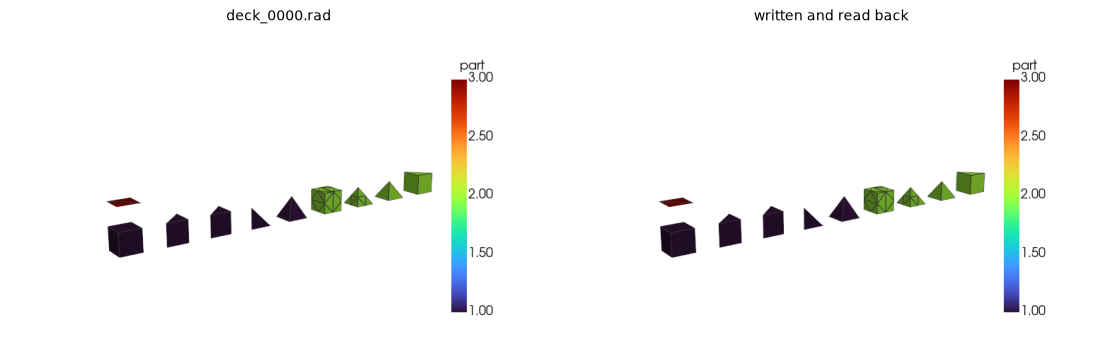

In [3]:
deck = mp.read(path('radioss', 'deck_0000.rad'))
out = os.path.join(TMP, 'copy_0000.rad')
mp.radioss.write(out, deck, stubs=True)
with open(out) as f:
    lines = f.read().splitlines()
print('\n'.join(lines[:12]))
print('...', len(lines), 'lines;', sum(line.startswith('/MAT') for line in lines), 'materials,',
      sum(line.startswith('/PROP') for line in lines), 'properties')
back = mp.read(out)
key = lambda m: sorted((c.type, len(c.data)) for c in m.cells)
print('same cells  :', key(back) == key(deck))
print('same regions:', sorted((r.kind, r.name) for r in back.regions) == sorted((r.kind, r.name) for r in deck.regions))
part = lambda m: [np.asarray(a, float) for a in m.cell_data['radioss:part']]
gallery([(to_grid(deck, cell_data={'part': part(deck)}), 'part', 'deck_0000.rad', None),
         (to_grid(back, cell_data={'part': part(back)}), 'part', 'written and read back', None)],
        ncols=2, zoom=1.2)

A quadratic mesh from gmsh becomes `/BRIC20` cards, through the Radioss entry of the node-order registry: the mid-edge nodes land on the edges again when the deck is read.

[('hexahedron20', 3)] same points: True


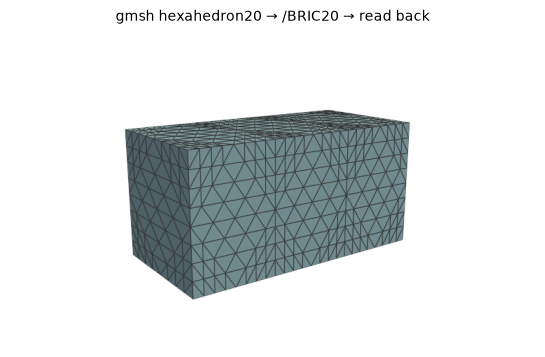

In [4]:
hex20 = mp.read(path('radioss', 'gmsh_hex20.msh'))
out = os.path.join(TMP, 'hex20_0000.rad')
mp.write(out, hex20)
again = mp.read(out)
print([(c.type, len(c.data)) for c in again.cells], 'same points:', np.allclose(again.points, hex20.points))
gallery([(curved(to_grid(again)), None, 'gmsh hexahedron20 → /BRIC20 → read back', None)], ncols=1)

## An MSC Marc deck, written and read back

`marc/hex20.dat` holds two 20-node bricks (type 21) with element and node sets. The writer keeps each element's `marc:type` and number, writes the sets as `DEFINE ELEMENT SET` / `DEFINE NODE SET` with `TO` ranges, and always uses `EXTENDED` format, whose 20-column reals take the shortest exact spelling, so coordinates come back bit for bit. No Marc licence was at hand, so the deck is checked by reading it back, not by Marc itself.

title               meshio++
extended
sizing                       0         2        32         0
elements                    21
define              node                set                 top_face
define              node                set                 top_not_x0
define              node                set                 x0_face
define              element             set                 both
define              element             set                 both_again
define              element             set                 left
define              element             set                 right
points identical: True
sets: ['both', 'both_again', 'left', 'right', 'top_face', 'top_not_x0', 'x0_face']


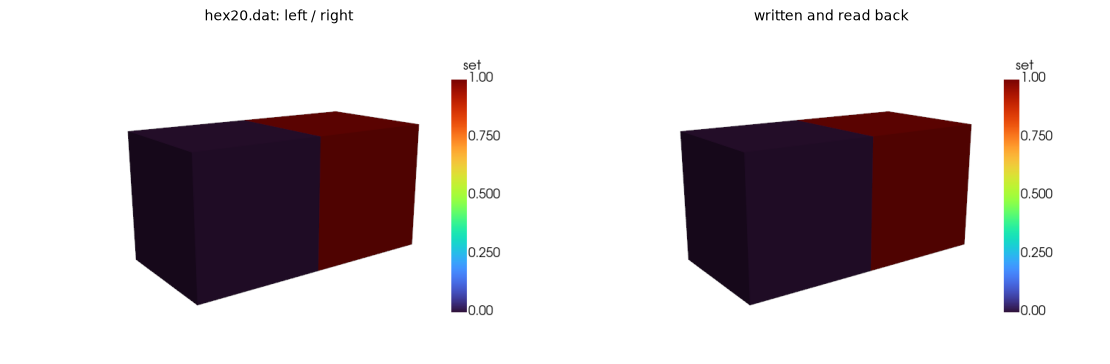

In [5]:
marc = mp.read(path('marc', 'hex20.dat'))
out = os.path.join(TMP, 'job.dat')
mp.write(out, marc, file_format='marc')
with open(out) as f:
    text = f.read().splitlines()
print('\n'.join(line for line in text if line.lower().startswith(('title', 'extended', 'sizing', 'elements', 'define'))))
back = mp.read(out)
print('points identical:', np.array_equal(back.points, marc.points))
print('sets:', sorted(r.name for r in back.regions))
sets = ['left', 'right']
gallery([(curved(to_grid(marc, cell_data={'set': region_array(marc, sets)})), 'set', 'hex20.dat: left / right', None),
         (curved(to_grid(back, cell_data={'set': region_array(back, sets)})), 'set', 'written and read back', None)],
        ncols=2, edges=False)

## A Femap series: one output set per step

`write_sequence` to a `.neu` writes the mesh with the first step, then one output set per step, each holding the step's point and cell data as output vectors. The series reads back as steps, and the native pipeline writes the same bytes. Vector data stays split into components, as Femap stores it.

time values: [1.0, 2.0, 3.0, 4.0]


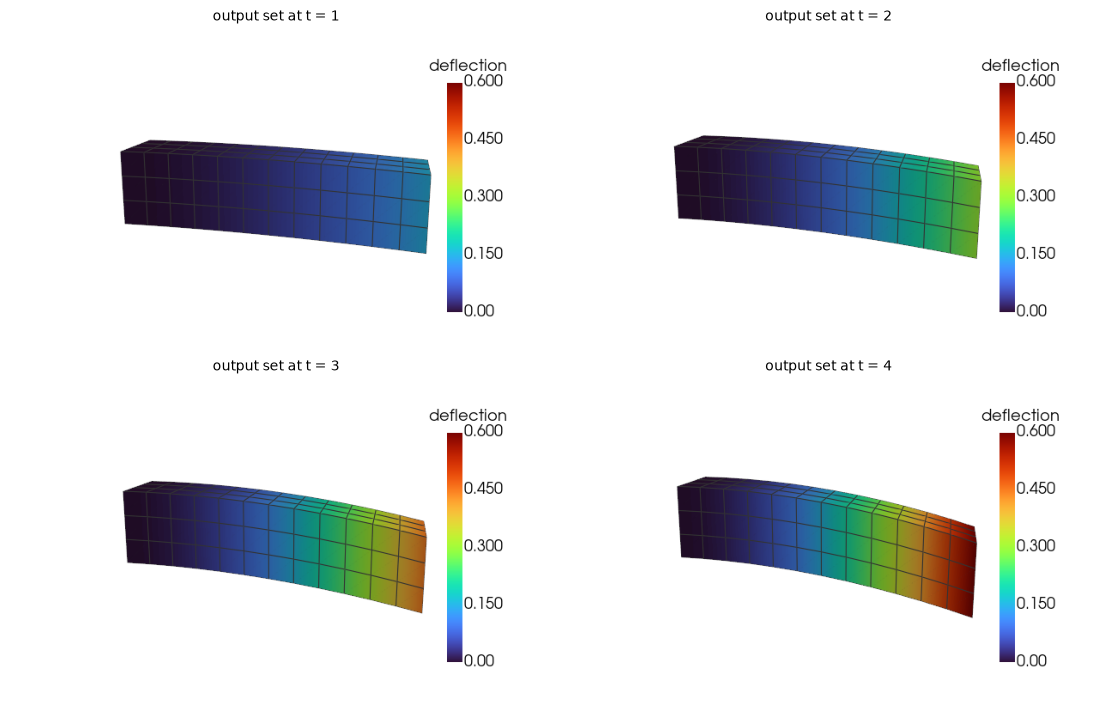

In [6]:
nx, ny, nz = 12, 3, 3
xs, ys, zs = np.meshgrid(np.linspace(0, 4, nx + 1), np.linspace(0, 1, ny + 1), np.linspace(0, 1, nz + 1), indexing='ij')
pts = np.column_stack([xs.ravel(), ys.ravel(), zs.ravel()])
idx = np.arange(len(pts)).reshape(nx + 1, ny + 1, nz + 1)
hexes = np.array([[idx[i, j, k], idx[i + 1, j, k], idx[i + 1, j + 1, k], idx[i, j + 1, k],
                   idx[i, j, k + 1], idx[i + 1, j, k + 1], idx[i + 1, j + 1, k + 1], idx[i, j + 1, k + 1]]
                  for i in range(nx) for j in range(ny) for k in range(nz)])


def step(t):
    w = 0.15 * t * (pts[:, 0] / 4.0) ** 2  # a cantilever's bending, growing with t
    return mp.Mesh(pts, [('hexahedron', hexes)], point_data={'deflection': w})


series = os.path.join(TMP, 'beam.neu')
mp.write_sequence(series, ((t, step(t)) for t in (1.0, 2.0, 3.0, 4.0)))
print('time values:', mp.read_metadata(series)['time_values'])
frames = [(t, m) for t, m in mp.read_sequence(series)]
items = []
for t, m in frames:
    grid = to_grid(m, point_data={'deflection': m.point_data['deflection']})
    grid.points[:, 2] -= m.point_data['deflection']
    items.append((grid, 'deflection', f'output set at t = {t:g}', (0, 0.6)))
gallery(items, ncols=2, size=(620, 380), view=(0.2, -1.0, 0.25))

## EnSight Fortran binary

A Fortran binary EnSight file frames every write in 4-byte record markers. It used to be refused with a misleading error, because the check looked for `Fortran Binary` at byte 0, where the marker sits. Both engines now write and read it, and VTK's EnSight reader reads what meshio++ writes.

first marker: 80 | first record: b'Fortran Binary'
meshio++ reads it back: True 0.6000000238418579
VTK reads 208 points and 108 cells


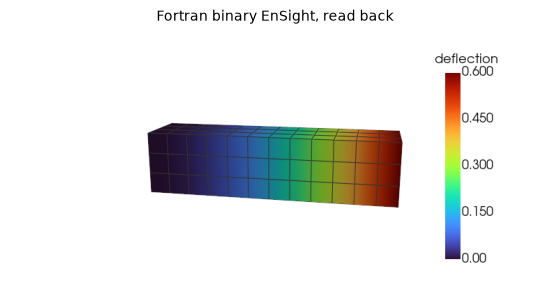

In [7]:
geo = os.path.join(TMP, 'fortran.case')
mp.ensight.write(geo, frames[-1][1], fortran=True)
with open(os.path.join(TMP, 'fortran.geo'), 'rb') as f:
    head = f.read(88)
print('first marker:', int.from_bytes(head[:4], 'little'), '| first record:', head[4:18])
back = mp.read(geo)
print('meshio++ reads it back:', np.allclose(back.points, frames[-1][1].points), back.point_data['deflection'].max())
reader = vtk.vtkEnSightGoldBinaryReader()
reader.SetCaseFileName(geo)
reader.Update()
block = reader.GetOutput().GetBlock(0)
print('VTK reads', block.GetNumberOfPoints(), 'points and', block.GetNumberOfCells(), 'cells')
gallery([(to_grid(back, point_data={'deflection': back.point_data['deflection']}), 'deflection',
          'Fortran binary EnSight, read back', (0, 0.6))], ncols=1, size=(760, 380), view=(0.2, -1.0, 0.25))

## Exodus quadratic hexahedra, as VTK reads them

Exodus numbers a 20-node brick's vertical edges after its top ring, VTK the other way round; the 27-node brick adds its face centres in a different order too. Until v16.17.0 meshio++ wrote the VTK order into Exodus files, so other Exodus readers put six nodes of every 20-node brick on the wrong edges. The Exodus tables are now in the node-order registry: VTK's Exodus reader puts every node of a written `hexahedron20` back at its own coordinates.

In [8]:
ref = np.array([[0, 0, 0], [1, 0, 0], [1, 1, 0], [0, 1, 0], [0, 0, 1], [1, 0, 1], [1, 1, 1], [0, 1, 1]], float)
edges = [(0, 1), (1, 2), (2, 3), (3, 0), (4, 5), (5, 6), (6, 7), (7, 4), (0, 4), (1, 5), (2, 6), (3, 7)]
pts20 = np.vstack([ref, [(ref[a] + ref[b]) / 2 for a, b in edges]])
cube = mp.Mesh(pts20, [('hexahedron20', np.arange(20)[None, :])])
exo = os.path.join(TMP, 'hex20.e')
mp.write(exo, cube)
reader = vtk.vtkExodusIIReader()
reader.SetFileName(exo)
reader.Update()
ug = reader.GetOutput().GetBlock(0).GetBlock(0)
cell = ug.GetCell(0)
got = np.array([ug.GetPoint(cell.GetPointId(k)) for k in range(20)])
print('VTK cell type:', cell.GetClassName(), '| largest node misplacement:', np.abs(got - pts20).max())

VTK cell type: vtkQuadraticHexahedron | largest node misplacement: 0.0


## Why some formats are read-only

Every format that is read but not written names its reason: result files have the solver as their only producer, and `vtx` and `szplt` are read through ADIOS2 and TecIO. The list below comes from the test declarations that also generate `doc/conformance.md`; a new format that reads without writing and without a reason fails the test suite.

In [9]:
import sys
sys.path.insert(0, os.path.join(os.path.dirname(MESHES)))
from conformance_spec import READ_ONLY  # noqa: E402

for fmt, reason in sorted(READ_ONLY.items()):
    print(f'{fmt:18s} {reason}')

abaqus_fil         Abaqus's result file: Abaqus is its only producer, and no downstream tool reads one written by anything else, so there is nothing to write back.
ansys_rst          Ansys's result file: Ansys is its only producer, and no downstream tool reads one written by anything else, so there is nothing to write back.
ansys_rst_cyclic   Not a file of its own: the full rotor that a static cyclic-symmetry `.rst` expands to, read from `ansys_rst`'s file.
frd                CalculiX (`ccx`)'s result file: CalculiX (`ccx`) is its only producer, and no downstream tool reads one written by anything else, so there is nothing to write back.
lsdyna_binout      LS-DYNA's result file: LS-DYNA is its only producer, and no downstream tool reads one written by anything else, so there is nothing to write back.
lsdyna_d3plot      LS-DYNA's result file: LS-DYNA is its only producer, and no downstream tool reads one written by anything else, so there is nothing to write back.
marc_t19           Mar